# How hard is a word? The level experiment

Wordwinnow assigns every word of a text a CEFR level, and the learner's own
level turns that into a study tier.

This notebook is the evidence behind the way a level is assigned to a word the
reference lists do not cover.

It answers, in order: what exactly is predicted, where the labels come from
and why they mean something, what the baselines are, whether a model beats
them and by how much, what each feature family adds, what the limitations are,
and whether the result justifies using a model in the product.

It runs in a few minutes from the repository root once `make setup`,
`make nltk-data`, and `make model` have been run, and it is stored with its
outputs.

In [1]:
from pathlib import (
    Path,
)
from typing import (
    Final,
)

from IPython.display import (
    Image,
)
from IPython.display import (
    display as show,
)
from pandas import (
    DataFrame,
)
from sklearn.inspection import (
    permutation_importance,
)

from wordwinnow.domain.cefr import (
    LEVELS_ASCENDING,
)
from wordwinnow.infrastructure.lexicon.reference_lists import (
    CsvReferenceLexicon,
)
from wordwinnow.infrastructure.lexicon.wordnet_semantics import (
    WordNetLexicalSemantics,
)
from wordwinnow.infrastructure.linguistics.wordfreq_frequency import (
    WordfreqFrequency,
)
from wordwinnow.infrastructure.ml.evaluation import (
    EvaluationReport,
)
from wordwinnow.infrastructure.ml.features import (
    encode,
)
from wordwinnow.services.ml.dataset import (
    build_dataset,
    class_distribution,
    split,
)
from wordwinnow.services.ml.experiment import (
    TEST_FRACTION,
    families_label,
    run_experiment,
)
from wordwinnow.services.ml.figures import (
    ABLATION_FIGURE,
    COMPARISON_FIGURE,
    CONFUSION_FIGURE,
)

SEED: Final = 42

OUTPUT: Final = Path(
    "output",
)

examples = build_dataset(
    reference_lexicon=CsvReferenceLexicon.from_directory(
        directory=Path(
            "../data/reference",
        ),
    ),
    frequency=WordfreqFrequency(),
    lexical_semantics=WordNetLexicalSemantics(),
)

len(
    examples,
)

9520

## 1. What is predicted

The target is a word's **lexical difficulty on the CEFR scale**: one of A1,
A2, B1, B2, C1, C2 for a lemma in one part of speech.

The scale is ordinal, so the primary measure is the **mean absolute level
error**, the average distance in levels between the prediction and the label,
with the share of predictions **within one level** beside it; a word predicted
one level off usually stays in its study tier, while a word predicted three
levels off changes tier for every learner from A2 to B2.

Macro-F1 and accuracy are reported too, because they show whether the rare
levels at both ends are predicted at all, which the ordinal measures can hide.

The product then turns the general level into a learner-specific tier with the
learner's declared level and target, which is a rule, not a model: no data
this project may use records what any particular learner knows, so learning
that mapping would mean inventing labels.

## 2. Where the labels come from

The labels are the two reference lists shipped under `data/reference`: the
CEFR-J Vocabulary Profile for A1 to B2 and the Octanove Vocabulary Profile for
C1 and C2, compiled by people, redistributed under their own licenses
(`data/reference/ATTRIBUTION.md`).

They are **external labels**: judgments made outside this project, which is
what makes agreement with them evidence.

The lists describe receptive vocabulary of textbooks and graded readers, one
level per lemma and part of speech; they are not a random sample of English,
they are not sense-specific, and the two lists were compiled by different
people with different methods, all of which the limitations below return to.

In [2]:
distribution = class_distribution(
    examples=examples,
)

total = len(
    examples,
)

DataFrame(
    data={
        "level": list(
            LEVELS_ASCENDING,
        ),
        "words": [distribution[level] for level in LEVELS_ASCENDING],
        "share": [f"{distribution[level] / total:.1%}" for level in LEVELS_ASCENDING],
    },
)

,level,words,share
0,A1,1004,10.5%
1,A2,1333,14.0%
2,B1,2387,25.1%
3,B2,2794,29.3%
4,C1,1055,11.1%
5,C2,947,9.9%


The classes are imbalanced: B2 alone is almost thirty percent of the words,
which is why the majority-class baseline is reported and why macro-F1 stands
beside accuracy.

## 3. The split and the protocol

One fifth of the words is held out, stratified by level, with a fixed seed;
everything that follows is fitted on the other four fifths and scored on the
held-out fifth, once.

Candidates are compared by five-fold stratified cross-validation on the
training split only, and the candidate with the lowest cross-validated level
error is the one scored on the held-out split as *the model*.

In [3]:
result = run_experiment(
    examples=examples,
    seed=SEED,
    output_dir=OUTPUT,
)

(
    training,
    test,
) = split(
    examples=examples,
    test_fraction=TEST_FRACTION,
    seed=SEED,
)

trained_on = len(
    training,
)

held_out = len(
    test,
)

print(
    f"{trained_on} words for training, {held_out} held out",
)

7616 words for training, 1904 held out


## 4. The baselines, and does the model beat them?

Three baselines, in order of strength:

- **majority class**: every word is B2;
- **the default heuristic**: five boundaries on the word's Zipf frequency, fitted
  once on this training split for macro-F1 and shipped since as the product's
  fallback;
- **the tuned heuristic**: the same five boundaries, refitted on the training
  split to minimize the level error.

In [4]:
def row(
    *,
    name: str,
    report: EvaluationReport,
) -> dict[str, object]:
    return {
        "method": name,
        "mean absolute level error": round(
            number=report.mean_absolute_level_error,
            ndigits=3,
        ),
        "within one level": round(
            number=report.within_one_level_accuracy,
            ndigits=3,
        ),
        "macro-F1": round(
            number=report.macro_f1,
            ndigits=3,
        ),
        "accuracy": round(
            number=report.accuracy,
            ndigits=3,
        ),
        "Spearman": round(
            number=report.spearman,
            ndigits=3,
        ),
    }


DataFrame(
    data=[
        row(
            name="majority class (B2)",
            report=result.majority_baseline,
        ),
        row(
            name="default heuristic",
            report=result.heuristic_default,
        ),
        row(
            name=f"tuned heuristic {result.tuned_thresholds.boundaries}",
            report=result.heuristic_tuned,
        ),
        row(
            name=f"model: {result.chosen.name}",
            report=result.chosen.validity,
        ),
    ],
)

,method,mean absolute level error,within one level,macro-F1,accuracy,Spearman
0,majority class (B2),1.157,0.655,0.076,0.294,0.000
1,default heuristic,0.843,0.809,0.376,0.380,0.652
2,"tuned heuristic (5.5, 4.8, 3.9, 3.15, 1.5)",0.811,0.846,0.320,0.357,0.641
3,model: ordinal_gradient_boosting on frequency+...,0.732,0.888,0.348,0.389,0.697


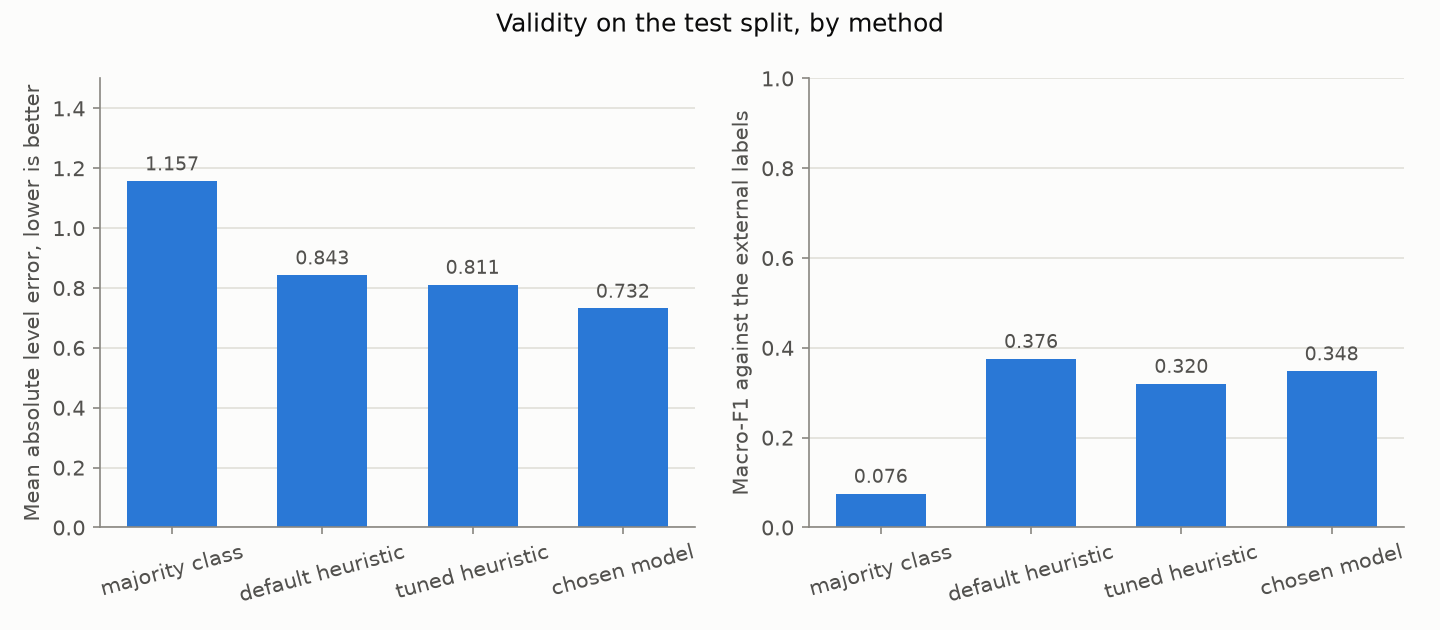

In [5]:
show(
    Image(
        filename=OUTPUT / COMPARISON_FIGURE,
    ),
)

The tuned heuristic lowers the level error but nearly stops predicting C2,
which the per-class table below shows: fitting five boundaries to the level
error pushes the last boundary to the bottom of the scale.

That is why the product keeps the default boundaries as its fallback: they
recall 0.455 of the C2 words, against 0.116 for the tuned ones
(`output/results.json` holds every per-class figure), because they were fitted
for macro-F1, which weighs every level equally, where the tuned ones are
fitted for the level error; the heuristic is a fallback rather than the
answer.

The model beats every baseline on every ordinal measure, and it pays for that
at the ends of the scale: it recalls fewer C2 words than either heuristic, as
the table below shows, and its macro-F1 is below the default heuristic's.

In [6]:
DataFrame(
    data=[
        {
            "level": entry.level,
            "support": entry.support,
            "precision": round(
                number=entry.precision,
                ndigits=3,
            ),
            "recall": round(
                number=entry.recall,
                ndigits=3,
            ),
            "F1": round(
                number=entry.f1,
                ndigits=3,
            ),
            "recall, tuned heuristic": round(
                number=tuned.recall,
                ndigits=3,
            ),
        }
        for (
            entry,
            tuned,
        ) in zip(
            result.chosen.validity.per_class,
            result.heuristic_tuned.per_class,
            strict=True,
        )
    ],
)

,level,support,precision,recall,F1,"recall, tuned heuristic"
0,A1,201,0.803,0.244,0.374,0.204
1,A2,267,0.369,0.416,0.391,0.300
2,B1,477,0.388,0.486,0.432,0.516
3,B2,559,0.419,0.433,0.426,0.370
4,C1,211,0.270,0.441,0.335,0.398
5,C2,189,0.667,0.074,0.133,0.116


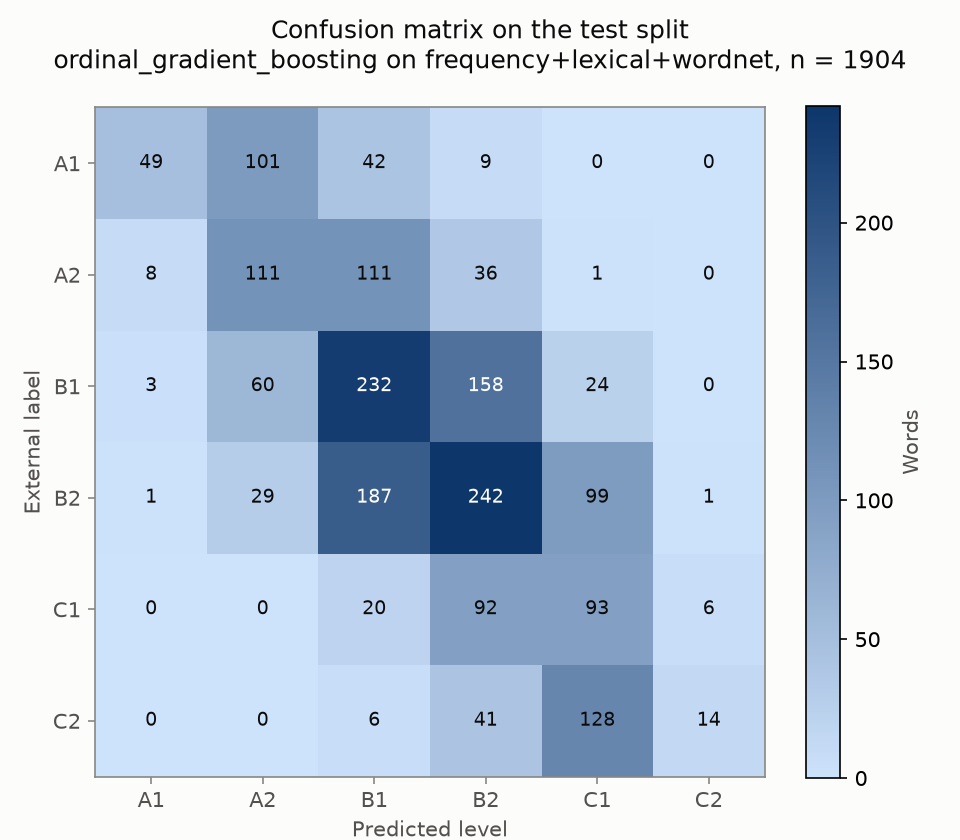

In [7]:
show(
    Image(
        filename=OUTPUT / CONFUSION_FIGURE,
    ),
)

Precision-recall and ROC areas are not reported: the heuristics produce no
class scores, the chosen model is a regressor whose output is a level rather
than a probability, and a one-versus-rest area over six ordinal classes
answers a question the product does not ask.

## 5. What each feature family adds

Three families, added one at a time so the experiment says what each one buys:

| Family | Features | Why it is defensible |
| --- | --- | --- |
| frequency | Zipf frequency of the lemma in wordfreq's English corpus | Frequency is the best single predictor of vocabulary acquisition order in the literature, and the heuristic is nothing but this feature |
| lexical | Character count; part of speech | Word length is the classic readability feature, and the lists label parts of speech differently |
| wordnet | Sense count in the part of speech; SemCor usage count; hyponym count of the most used sense; WordNet's semantic category of that sense | Polysemy and corpus usage track how established a word is, generality tracks how basic it is, and a category such as `noun.food` against `noun.attribute` is a coarse proxy for concreteness |

A suffix list of Latinate endings and a syllable count were tried first and
dropped: the suffix list was a hand-picked vocabulary, and neither moved the
cross-validated error once the WordNet family was in.

Depth in the hypernym hierarchy, synonym count, and the number of synsets
across all parts of speech were also measured and dropped for the same reason.

In [8]:
DataFrame(
    data=[
        {
            "families": families_label(
                families=candidate.families,
            ),
            "estimator": candidate.model_kind,
            "cross-validated level error": round(
                number=candidate.cross_validated_error,
                ndigits=3,
            ),
            "held-out level error": round(
                number=candidate.validity.mean_absolute_level_error,
                ndigits=3,
            ),
            "held-out within one": round(
                number=candidate.validity.within_one_level_accuracy,
                ndigits=3,
            ),
            "held-out macro-F1": round(
                number=candidate.validity.macro_f1,
                ndigits=3,
            ),
            "chosen": "yes" if candidate is result.chosen else "",
        }
        for candidate in sorted(
            result.candidates,
            key=lambda candidate: candidate.cross_validated_error,
        )
    ],
)

,families,estimator,cross-validated level error,held-out level error,held-out within one,held-out macro-F1,chosen
0,frequency+lexical+wordnet,ordinal_gradient_boosting,0.753,0.732,0.888,0.348,yes
1,frequency+lexical+wordnet,logistic_regression,0.791,0.787,0.818,0.373,
2,frequency+lexical,ordinal_gradient_boosting,0.819,0.797,0.860,0.286,
3,frequency,ordinal_gradient_boosting,0.824,0.824,0.851,0.244,
4,frequency+lexical,logistic_regression,0.826,0.829,0.793,0.329,
5,frequency+lexical+wordnet,gradient_boosting,0.832,0.818,0.801,0.400,
6,frequency,logistic_regression,0.854,0.860,0.778,0.292,
7,frequency,gradient_boosting,0.887,0.894,0.777,0.319,
8,frequency+lexical,gradient_boosting,0.911,0.890,0.783,0.344,


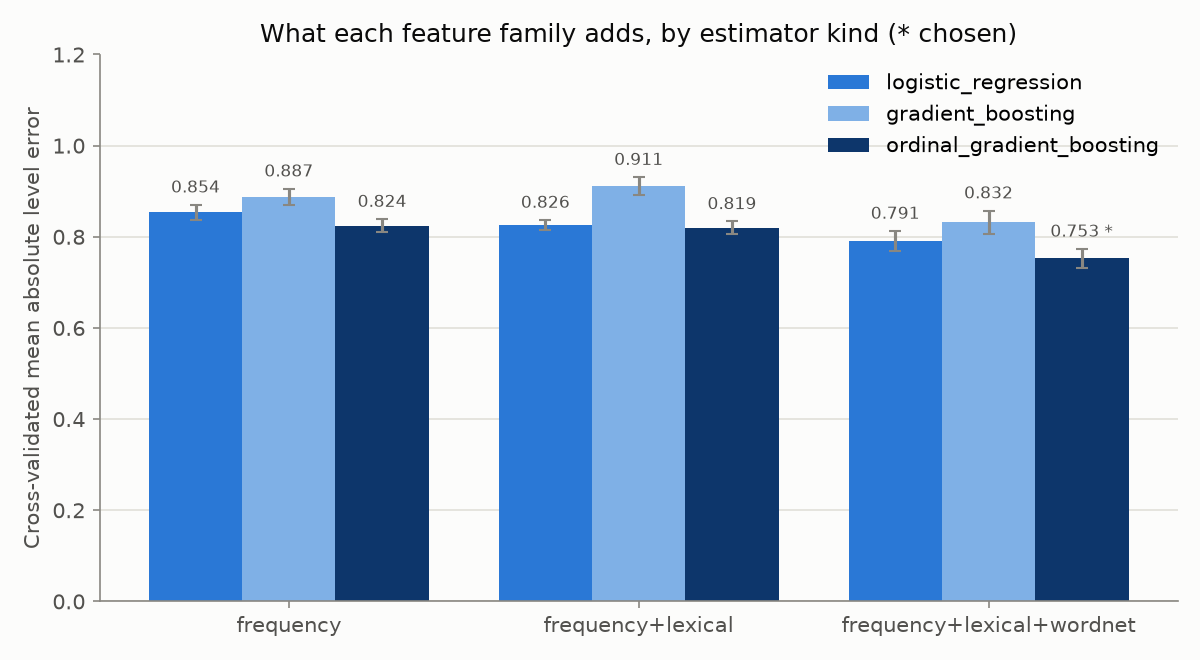

In [9]:
show(
    Image(
        filename=OUTPUT / ABLATION_FIGURE,
    ),
)

In [10]:
matrix = encode(
    features=[example.features for example in test],
    families=result.chosen.families,
)

importance = permutation_importance(
    estimator=result.estimator.pipeline,
    X=matrix,
    y=[example.level.rank for example in test],
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=SEED,
)

columns = result.estimator.metadata.feature_columns

DataFrame(
    data={
        "feature": columns,
        "level error increase when shuffled": importance.importances_mean.round(
            decimals=4,
        ),
    },
).sort_values(
    by="level error increase when shuffled",
    ascending=False,
).head(
    n=12,
).reset_index(
    drop=True,
)

,feature,level error increase when shuffled
0,zipf_frequency,0.3952
1,usage_count,0.0635
2,character_count,0.0288
3,part_of_speech_verb,0.0241
4,sense_count,0.0137
5,category_noun.artifact,0.0104
6,part_of_speech_noun,0.0082
7,hyponym_count,0.0077
8,category_noun.food,0.0067
9,category_adj.pert,0.0056


Frequency carries most of the signal, the SemCor usage count is the second
feature, and the semantic category columns share the rest, which is what the
univariate view below shows in plain terms.

In [11]:
frame = DataFrame(
    data={
        "category": [example.features.category or "none" for example in examples],
        "level": [example.level.rank for example in examples],
    },
)

by_category = (
    frame.groupby(
        by="category",
    )["level"]
    .agg(
        func=[
            "count",
            "mean",
        ],
    )
    .query(
        expr="count >= 100",
    )
    .sort_values(
        by="mean",
    )
)

by_category["mean level"] = by_category["mean"].round(
    decimals=2,
)

by_category[
    [
        "count",
        "mean level",
    ]
]

,count,mean level
category,,
noun.time,107,2.21
noun.food,104,2.35
noun.artifact,665,2.94
noun.animal,100,2.98
noun.location,115,3.04
noun.group,180,3.08
noun.communication,516,3.25
noun.act,495,3.34
noun.cognition,304,3.36


Words whose most used sense is a food, a time, or an artifact sit around A2
and B1 on average; words whose most used sense is an attribute or a pertainym
adjective sit around B2, which is the concreteness effect the category feature
stands in for.

## 6. What fidelity to a heuristic would have hidden

A model trained on labels a heuristic produced can report its agreement with
that heuristic as accuracy, which says nothing about CEFR levels.

The same protocol here, for the chosen configuration, gives the number below.

In [12]:
DataFrame(
    data=[
        row(
            name="model trained and scored on the heuristic's pseudo-labels",
            report=result.fidelity,
        ),
        row(
            name="the same configuration scored on the external labels",
            report=result.chosen.validity,
        ),
    ],
)

,method,mean absolute level error,within one level,macro-F1,accuracy,Spearman
0,model trained and scored on the heuristic's ps...,0.004,1.000,0.996,0.996,0.999
1,the same configuration scored on the external ...,0.732,0.888,0.348,0.389,0.697


Near-perfect fidelity to a heuristic says only that a model can reproduce five
thresholds on one feature; it says nothing about CEFR levels, and the
external-label row is the only one that does.

## 7. The learner's declared level is a reference point, not a label

The product never predicts a learner's level; the learner declares it, and the
same text yields different tiers for different declarations.

The table runs the shipped pipeline over the sample story, Arthur Conan
Doyle's "A Scandal in Bohemia", without the dictionary, for each declared
level with the default target one above it.

In [13]:
from wordwinnow.application.use_cases.process_an_analysis import (
    run_pipeline,
)
from wordwinnow.domain.learner import (
    LearnerProfile,
    default_target_level,
)
from wordwinnow.domain.study import (
    StudyTier,
)
from wordwinnow.infrastructure.composition import (
    build_linguistic_adapters,
    build_pipeline,
)
from wordwinnow.infrastructure.dictionary.disabled import (
    DisabledDictionary,
)
from wordwinnow.infrastructure.settings import (
    Settings,
)
from wordwinnow.infrastructure.sources.custom_text import (
    read_custom_text,
)

settings = Settings(
    reference_lists_dir=Path(
        "../data/reference",
    ),
    level_model_path=Path(
        "../models/cefr_level_model.joblib",
    ),
)

pipeline = build_pipeline(
    adapters=build_linguistic_adapters(
        settings=settings,
    ),
    dictionary=DisabledDictionary(),
    dictionary_concurrency=1,
)

text = read_custom_text(
    path=Path(
        "../data/corpus/a-scandal-in-bohemia.txt",
    ),
).text

rows: list[dict[str, object]] = []

for level in LEVELS_ASCENDING:
    outcome = await run_pipeline(
        text=text,
        profile=LearnerProfile(
            level=level,
            target_level=default_target_level(
                level=level,
            ),
        ),
        include_dictionary=False,
        pipeline=pipeline,
    )

    counts = {tier: sum(1 for item in outcome.items if item.tier is tier) for tier in StudyTier}

    rows.append(
        {
            "declared level": level,
            **counts,
        },
    )

DataFrame(
    data=rows,
)

,declared level,focus,stretch,review,known
0,A1,677,832,0,0
1,A2,659,486,364,0
2,B1,680,152,677,0
3,B2,474,12,1023,0
4,C1,152,0,1357,0
5,C2,12,0,1497,0


## 8. Conclusions, and what they do not say

**What is justified.** On 1,904 held-out words with external labels, an
ordinal gradient-boosting model over the frequency, lexical, and WordNet
families predicts a word's level with a lower mean level error and a higher
within-one-level share than five tuned frequency thresholds; the WordNet
family is what buys the difference, and within it the SemCor usage count
carries the most, by the permutation importances above.

**What it gives up.** It pulls its answers toward the middle of the scale: of
the 1,904 held-out words, 189 are C2 and the model answers C2 for 21, so a
product with the model places fewer words at C2 than either heuristic would.

**What the product does with it.** The model is the default when its file exists,
which `make model` produces in under a minute and the Docker image builds for
itself; without the file the default frequency boundaries stand in, and every
level in a report says which of the three sources assigned it.

**What is not justified.** Nothing here says what a particular learner knows,
how well the lists' levels transfer to words outside them, which are exactly
the words the model is used for, or how a word's level depends on its sense in
context.

**Limitations.**

- The lists cover about ten thousand lemmas from two sources with different
  methods, and the model's exact accuracy is 0.422 on the CEFR-J words and
  0.268 on the Octanove words (`output/results.json`), a gap that also
  reflects that Octanove holds only the C1 and C2 words the model predicts
  least well.
- One label per lemma and part of speech ignores senses: CEFR-J lists the noun
  `dive` at B1 without naming a meaning, Octanove lists it at C2 as a run-down
  bar, and the lower level is the one a learner sees.
- At run time the part of speech comes from a tagger, whose errors this
  evaluation never sees.
- One split, one seed, fixed hyperparameters: the numbers are estimates with a
  spread the cross-validation columns show, not a leaderboard.

**Does this justify using machine learning in the product?** Modestly, yes: a
small, transparent model with a defensible target and a measured gain over a
transparent baseline, at the cost of a derived file the repository does not
have to carry; a larger model with no better labels would not have been.